### Transport Though Benzene Molecule
In this tutorial, we do the procedure for timedependent transport through a benzene molecule, which by now have been seen many times. The structure is imported from the built-in library, so we do not worry about the intitial structure creation. In this tutorial we furthermore bring out the Non-equilibrium capabilities of TranSiesta, meaning we in practice use TranSiesta to get a parametrisation of the Hamiltonian in voltage, whereafter we say this voltage depends on time.  

In [1]:
import matplotlib.pyplot as plt
import sisl
import numpy as np
from Zandpack.TimedependentTransport import TD_Transport
from Structures.Structures import Benzene_EU, Benzene_ED, Benzene_Dev
from Zandpack.FittingTools import find_correction

Directory called EM already exists! Remove it? (y/reuse/n)
No atoms overlapping within 0.3 Å!
Directory called EP already exists! Remove it? (y/reuse/n)
No atoms overlapping within 0.3 Å!
Directory called Device already exists! Remove it? (y/reuse/n)
No atoms overlapping within 0.3 Å!
[[20, 21, 22, 23], [24, 25, 26, 27]]
Running Siesta electrode calculation in Directory: EM!



/home/aleksander/.local/lib/python3.10/site-packages/seekpath/hpkot/__init__.py:350: EdgeCaseWarning: aP lattice, but the k_alpha3 angle is almost equal to 90 degrees
  warnings.warn(
/home/aleksander/.local/lib/python3.10/site-packages/seekpath/hpkot/__init__.py:355: EdgeCaseWarning: aP lattice, but the k_beta3 angle is almost equal to 90 degrees
  warnings.warn(
/home/aleksander/.local/lib/python3.10/site-packages/seekpath/hpkot/__init__.py:360: EdgeCaseWarning: aP lattice, but the k_gamma3 angle is almost equal to 90 degrees
  warnings.warn(
Job completed


Running Siesta electrode calculation in Directory: EP!



Job completed


Running TranSiesta calculation in Directory: Device!



Job completed
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG


Running Siesta-analyse in Directory:Device!

Running TB-Trans in Directory: Device!


 Building ES - H - Self Energies 

[0]

 Overlap Included!



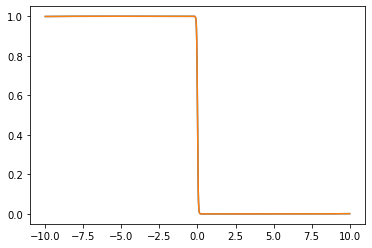

In [2]:
line = np.linspace(-4, 4, 80) + 1j * 1e-2     
line = np.vstack((line, line))                # Energy Sampling
#Benzene_EU =  # Benzene_EU.move([0, 0.25, 0])
#Benzene_ED =  # Benzene_ED.move([0,-0.25, 0])

Test = TD_Transport([Benzene_EU, 
                     Benzene_ED], 
                     Benzene_Dev, 
                     kT_i=[0.025, 0.025])

Test.Make_Contour(line, 18, pole_mode="JieHu2011")
Test.Electrodes(semi_infs=["+a2", "-a2"],kp = [[1,50,1], [1,50,1]] )
Test.make_device()
Test.run_electrodes()
Test.run_device()
Test.read_data()


 Subbed transmission vs TBtrans transmission. 

Calculating matrix elements of inverse



/home/aleksander/.local/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


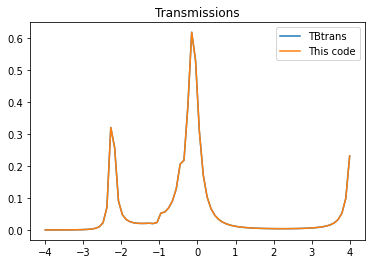

/home/aleksander/.local/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


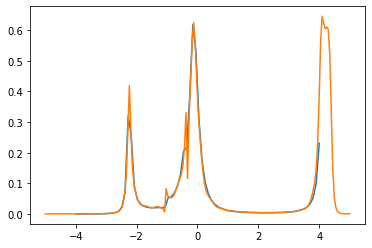

Normal plot


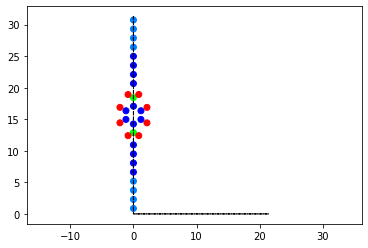

In [40]:
Test.Inspect_Transmission(0,1)
plt.show()
Test.Device.Visualise()

In [38]:
Test.reset_all_fits()
Eg       = np.linspace(-5,5,300)
NL       = 21
E        = np.linspace(-4,4,NL)
number   = 0.25
G1       = np.ones(NL)[None,:]*number
init_G   = [G1,G1]
init_E   = [E[None,:], E[None,:]]
alpha_PO = 0.001

min_tol = np.ones((1,NL))*0
min_tol1, min_tol2 = min_tol.copy(),min_tol.copy()

# In[]
def run_mini(its,method, elecs = None):
    Test.Fit(fact = 0.6,                            # Redundant when we give init_E and init_G
          Fallback_W = 5.0,                    # Redundant\n",
          NumL = NL,                           # Not redundant\n",
          fit_mode      = 'all',                    # Important to choose mode\n",
          force_PSD     = True,                # the self-energies are not positive semidefinite
          force_PSD_tol = [min_tol1,
                           min_tol2], # 
          use_analytical_jac = False,           # Important for speed
          min_method = method,                # Choose from any scipy.optimize.minimize method
          ebounds = (-5.5,5.5),                # bounds on centres
          wbounds = (0.001, 3),                # bounds on widths
          gbounds = (None, None),              # bounds on sizes, redundant right now
          tol = 1e-5,                         # any negative value with mean we fit all matrix elements of \\Gamma
          options = {'disp':True,              # Minimizer options
                     'maxiter':its, 
                     'gtol':1e-10, 
                     #'iprint':1,
                     }, 
          fit_real_part = False,              # 
          alpha_PO = alpha_PO,                # Repulsion
          init_E   = init_E,                    # Give initial ei's and gi's
          init_G   = init_G,
          which_e  = elecs
          )
    C = find_correction(Test)
    Test.Renormalise_H(C)


run_mini(0,'SLSQP')

Finding Lambda matrices:

--------------------
Optimizing Lorentzian Expansion
--------------------

16
Iteration limit reached    (Exit mode 9)
            Current function value: -5.252507862810247
            Iterations: 1
            Function evaluations: 43
            Gradient evaluations: 1
Lorentzian fit took 0.8057138919830322 seconds.
Finding Lambda matrices:

--------------------
Optimizing Lorentzian Expansion
--------------------

22
Iteration limit reached    (Exit mode 9)
            Current function value: -5.25407674670076
            Iterations: 1
            Function evaluations: 43
            Gradient evaluations: 1
Lorentzian fit took 1.0166563987731934 seconds.


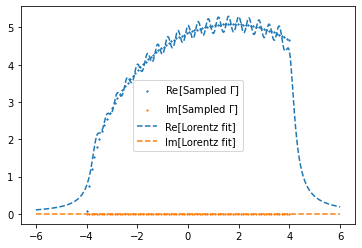

/home/aleksander/.local/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Finding eigenvalues and eigenvectors
Maximum of eigenvalues of Lorentzian Gammas: 2.983177
Minimum of eigenvalues of Lorentzian Gammas: -6e-06
If the minimum is negative, you should take extra care!
( if minimum negative Check eigenvalues of $\Gamma$)


/home/aleksander/Desktop/Input_hpc_master/PythonModules/Zandpack/Zandpack/TimedependentTransport.py:1017: RuntimeWarning: overflow encountered in exp
  f   = 1/(1 + np.exp((e - mu_dev)/kT_dev))


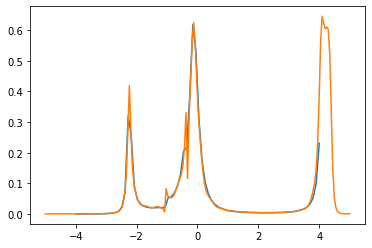

In [44]:
Test.Inspect_Lorentzian_fit(0,0,0,7,7, Emin = -6, Emax = 6,n_samples=500)
plt.show()
Test.Inspect_transmission_from_hilbert_transform(E=np.linspace(-5,5,200), eta=1e-2)
Test.tofile('Mol')

## Nonequilibrium steadystate Hamiltonian
Now that we have a good fit, we want to model how the potential shifts across the device region. Here we do
a series of transiesta calculations with different bias. Afterwards you will take the code shown below and copy it into the Bias.py file and do the calculation.

In [45]:
Vi = np.linspace(-.4, .4, 5)
Vi = Vi[np.argsort(np.abs(Vi))] # Order after absolute value
# Run Bias calculation with V_l/r =  +/- Vi/2
Test.run_device_non_eq(Vi)


Directory called Device_V0.0 already exists! Remove it? (y/reuse/n)
No atoms overlapping within 0.3 Å!
0
Running TranSiesta calculation in Directory: Device_V0.0!



/home/aleksander/.local/lib/python3.10/site-packages/seekpath/hpkot/__init__.py:350: EdgeCaseWarning: aP lattice, but the k_alpha3 angle is almost equal to 90 degrees
  warnings.warn(
/home/aleksander/.local/lib/python3.10/site-packages/seekpath/hpkot/__init__.py:355: EdgeCaseWarning: aP lattice, but the k_beta3 angle is almost equal to 90 degrees
  warnings.warn(
/home/aleksander/.local/lib/python3.10/site-packages/seekpath/hpkot/__init__.py:360: EdgeCaseWarning: aP lattice, but the k_gamma3 angle is almost equal to 90 degrees
  warnings.warn(
Job completed
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG


Running Siesta-analyse in Directory:Device_V0.0!

Running TB-Trans in Directory: Device_V0.0!

Directory called Device_V-0.2 already exists! Remove it? (y/reuse/n)
No atoms overlapping within 0.3 Å!
0
Running TranSiesta calculation in Directory: Device_V-0.2!



/home/aleksander/.local/lib/python3.10/site-packages/seekpath/hpkot/__init__.py:350: EdgeCaseWarning: aP lattice, but the k_alpha3 angle is almost equal to 90 degrees
  warnings.warn(
/home/aleksander/.local/lib/python3.10/site-packages/seekpath/hpkot/__init__.py:355: EdgeCaseWarning: aP lattice, but the k_beta3 angle is almost equal to 90 degrees
  warnings.warn(
/home/aleksander/.local/lib/python3.10/site-packages/seekpath/hpkot/__init__.py:360: EdgeCaseWarning: aP lattice, but the k_gamma3 angle is almost equal to 90 degrees
  warnings.warn(
Job completed


Running Siesta-analyse in Directory:Device_V-0.2!

Running TB-Trans in Directory: Device_V-0.2!



...

Running TB-Trans in Directory: Device_V-0.4!

Directory called Device_V0.4 already exists! Remove it? (y/reuse/n)
No atoms overlapping within 0.3 Å!
3
Running TranSiesta calculation in Directory: Device_V0.4!



/home/aleksander/.local/lib/python3.10/site-packages/seekpath/hpkot/__init__.py:350: EdgeCaseWarning: aP lattice, but the k_alpha3 angle is almost equal to 90 degrees
  warnings.warn(
/home/aleksander/.local/lib/python3.10/site-packages/seekpath/hpkot/__init__.py:355: EdgeCaseWarning: aP lattice, but the k_beta3 angle is almost equal to 90 degrees
  warnings.warn(
/home/aleksander/.local/lib/python3.10/site-packages/seekpath/hpkot/__init__.py:360: EdgeCaseWarning: aP lattice, but the k_gamma3 angle is almost equal to 90 degrees
  warnings.warn(
Job completed


Running Siesta-analyse in Directory:Device_V0.4!



Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG


Running TB-Trans in Directory: Device_V0.4!



We now have a sampling of the Hamiltonian at different voltages! These values are stored in the attributes "Test.calculated_bias" and "Test.calculated_neq_H_ortho". It should be noted that the calls to "diagonalise", "get_propagation_quantities" and "get_dense_matrices_purenp" has been called here already. This is because the "run_device_non_eq" function call has some internal dependencies on these calls. 


We now use the calculated Hamiltonians at each bias to make a function that can give intermediate values through interpolation:

In [59]:
from Zandpack.Interpolation import make_spline
# Save the elements to a npz archive
np.savez('NoneqHam',
        V = Test.calculated_bias,
        Hv = Test.calculated_neq_H_ortho
    )
# This is how you should be getting the 
Hv = make_spline(
                 Test.calculated_bias,
                 Test.calculated_neq_H_ortho
                )





We now have the Hamiltonian of the system parametrised over different voltages. We can use this to construct our timedependent Hamiltonian in our first approximation. Copy this to your Bias.py file.


In [60]:
s = 50
w = 0.1
A = 0.399

def Pulse(t):
    return A*np.exp(-t**2/s**2) * np.sin(w * t)

def bias(t,a):
    if a == 0: return +Pulse(t)/2
    if a == 1: return -Pulse(t)/2

H0 = np.load('Mol/Arrays/H_Ortho.npy')#Test.Hdense[:,0,:,:]
def dH(t, sigma):
    V = bias(t,1) - bias(t,0)
    return Hv(V) - H0 #  Gives H(V(t)) when added to H0



You can make animated graphics of how the Hamiltonian elements looks throughout the pulse if you save the scatterplot at a series of times and stitch them together using the "convert"-tool available in Ubuntu. Below we do it for the onsite elements viewed from the side.

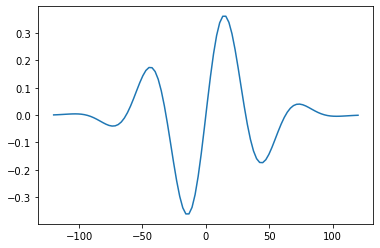

/home/aleksander/.local/lib/python3.10/site-packages/matplotlib/collections.py:193: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


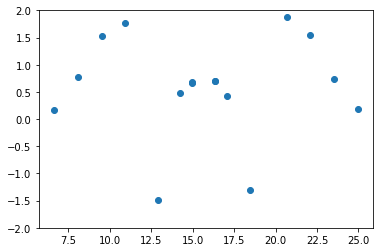

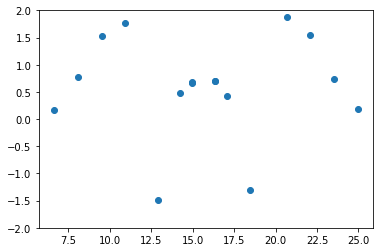

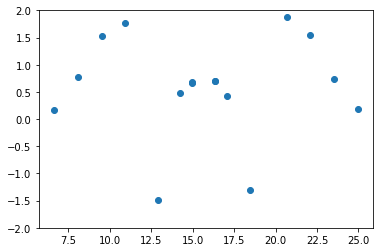

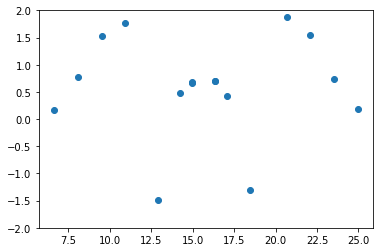

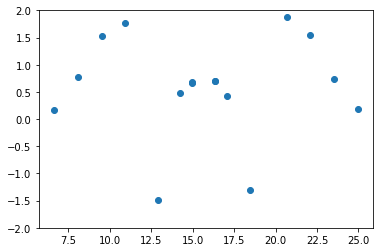

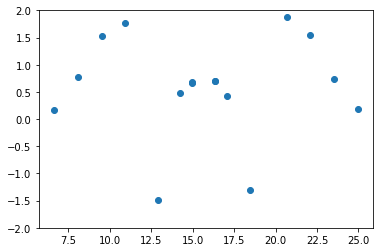

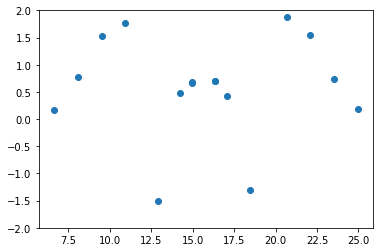

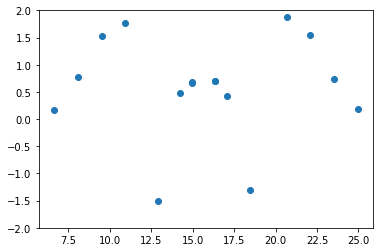

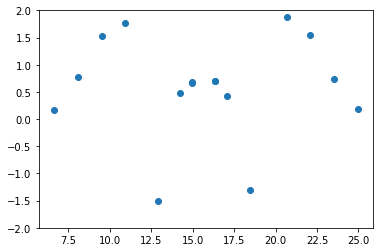

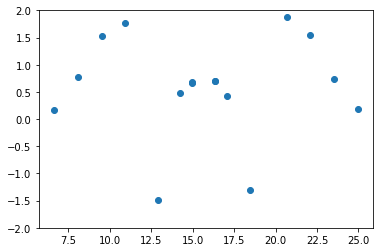

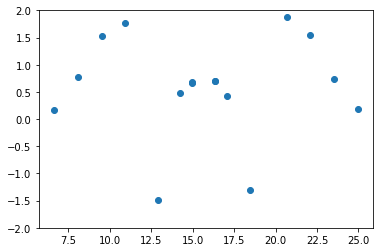

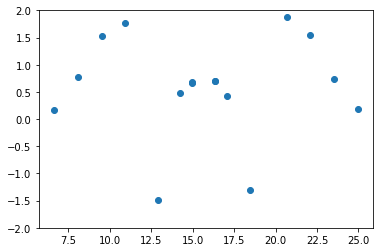

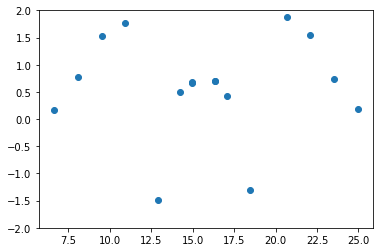

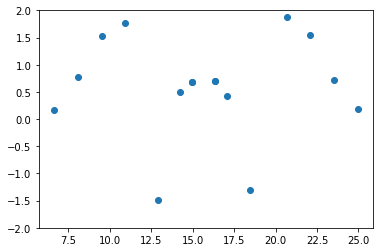

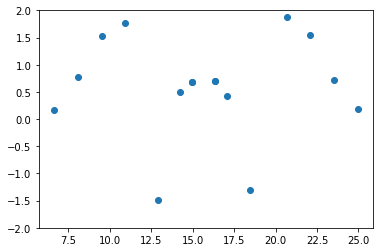

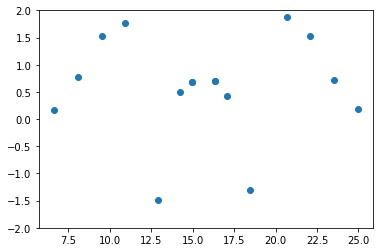

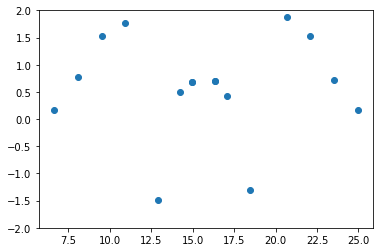

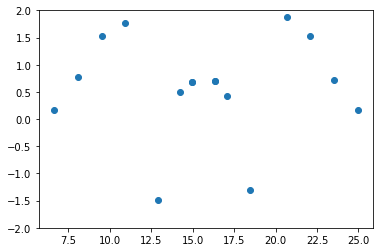

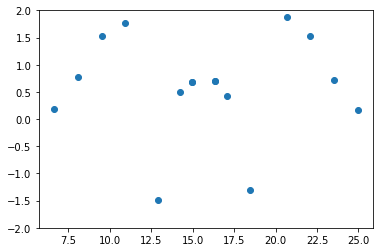

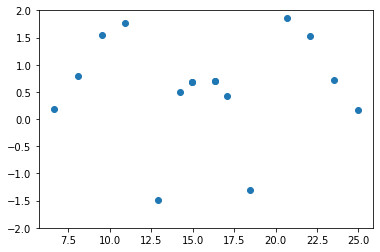

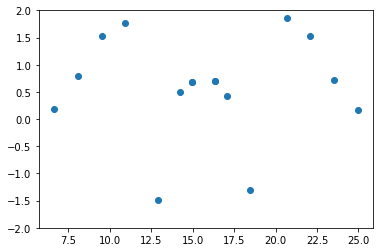

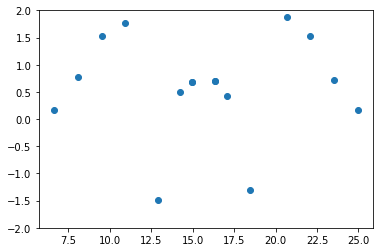

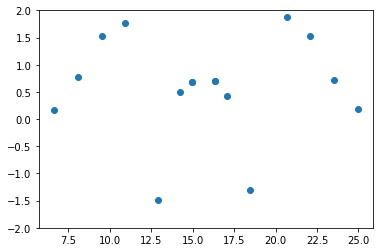

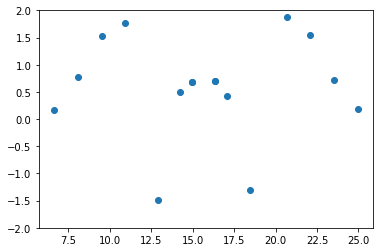

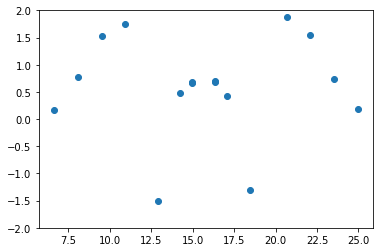

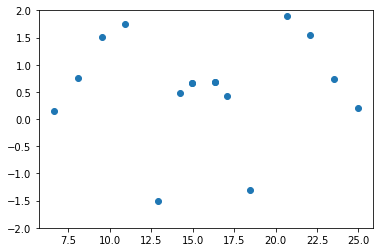

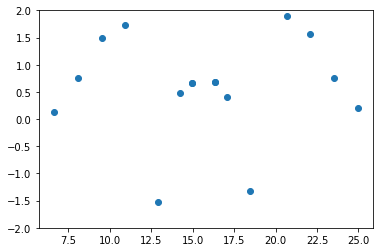

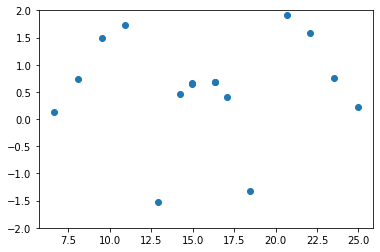

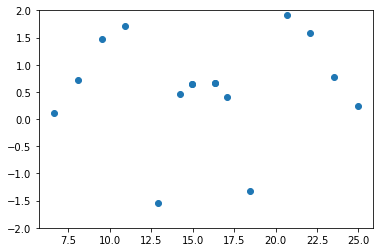

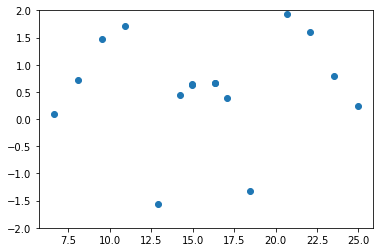

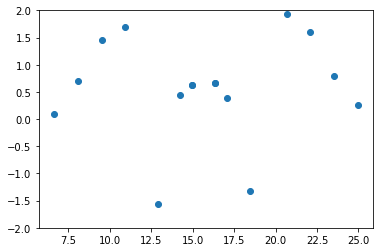

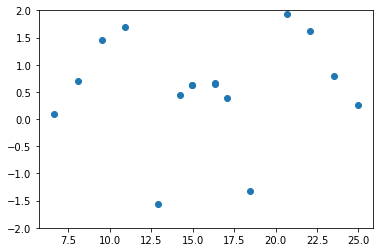

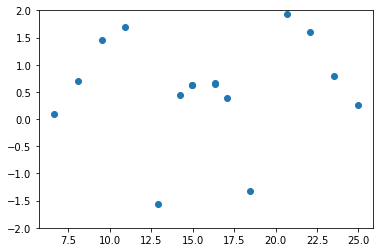

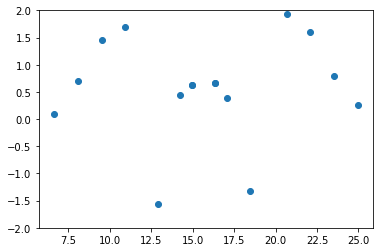

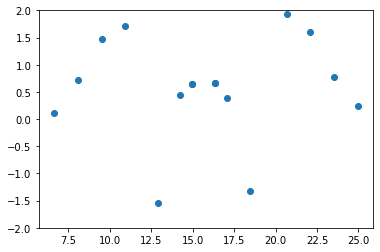

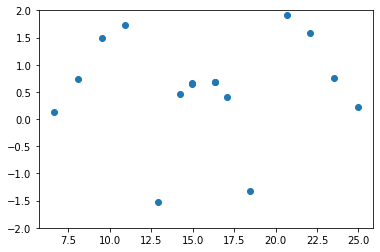

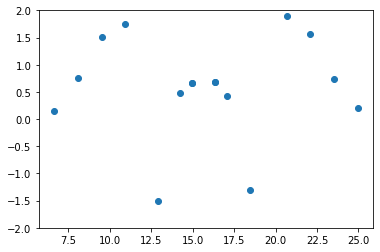

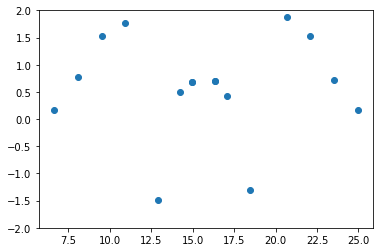

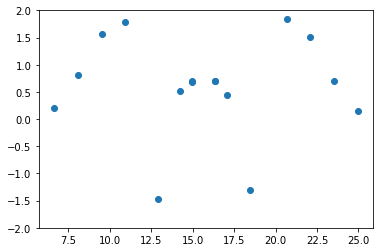

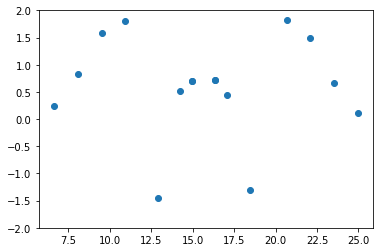

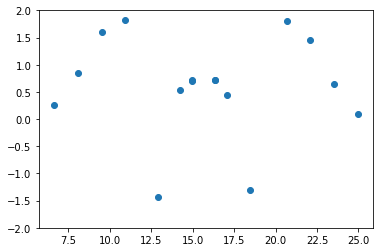

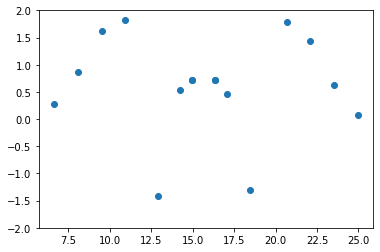

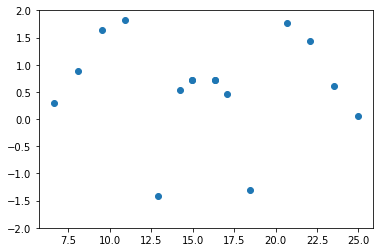

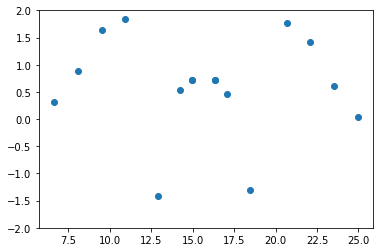

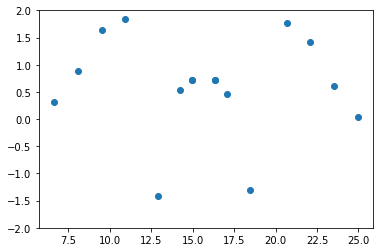

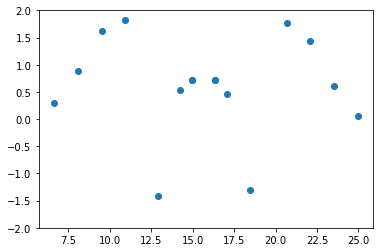

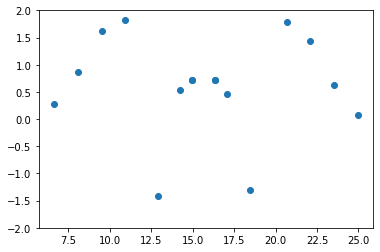

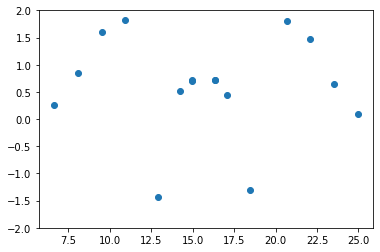

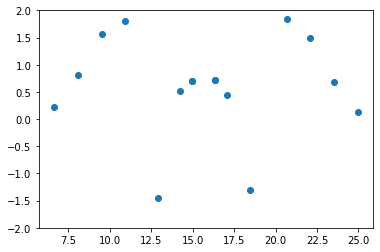

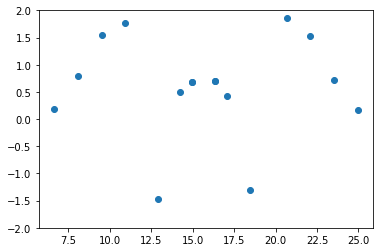

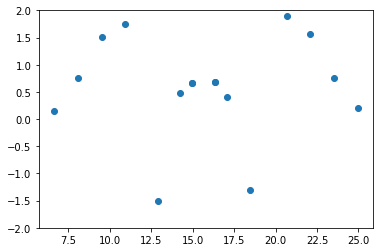

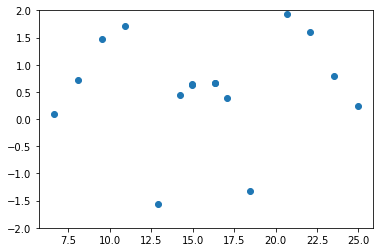

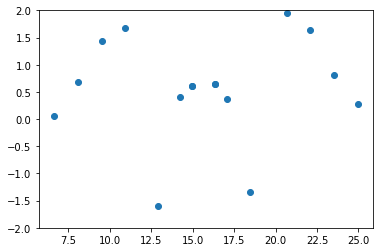

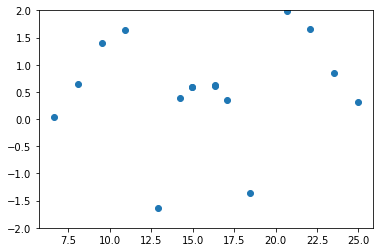

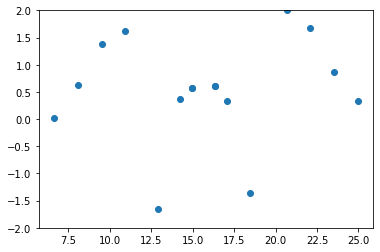

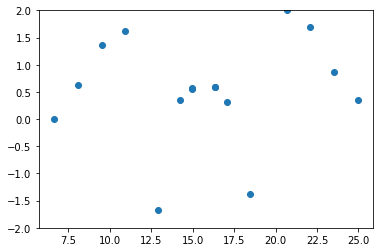

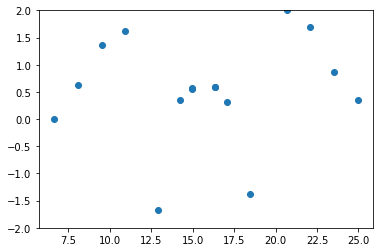

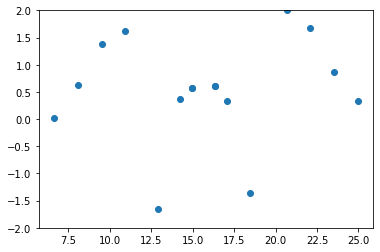

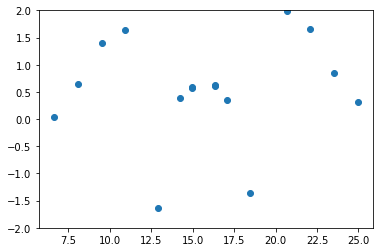

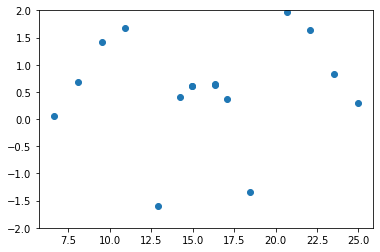

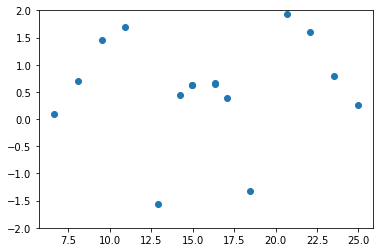

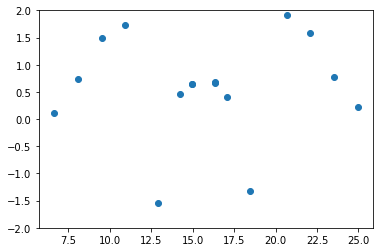

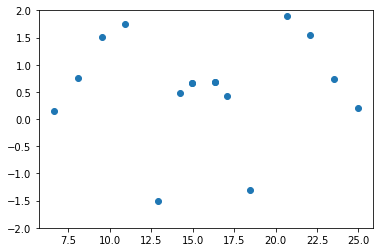

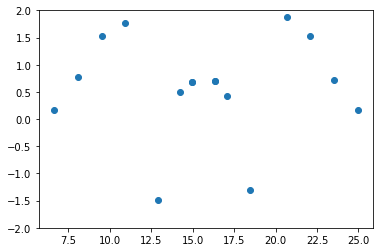

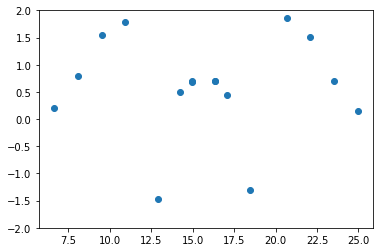

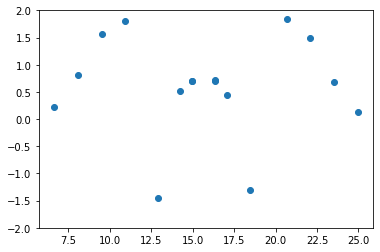

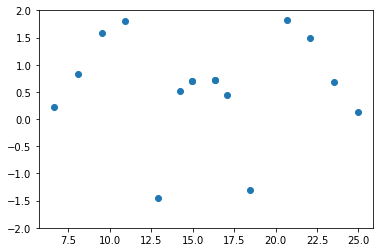

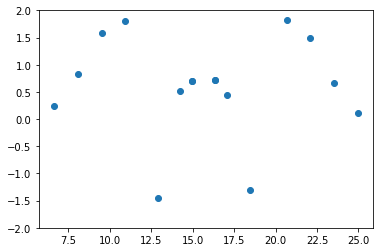

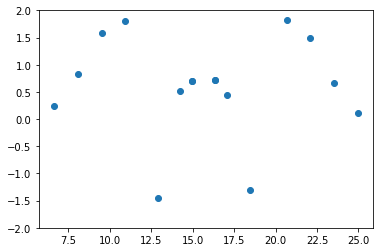

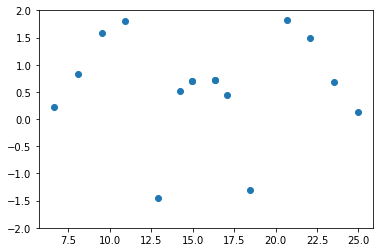

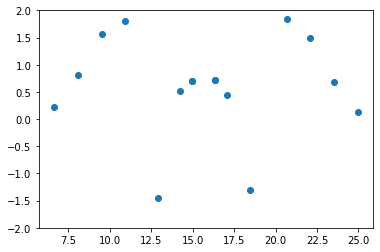

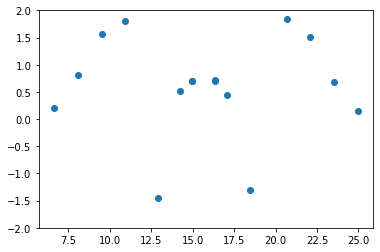

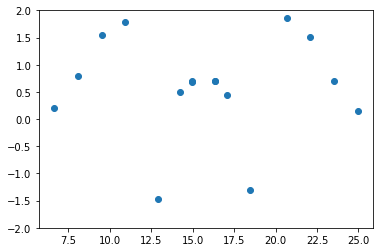

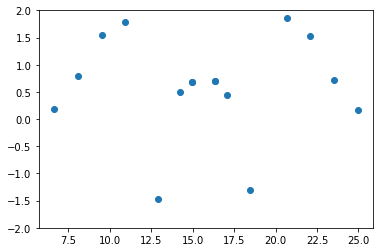

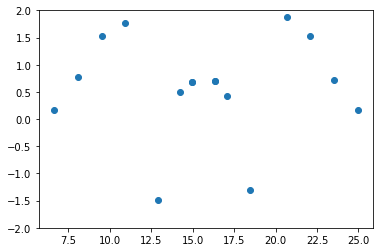

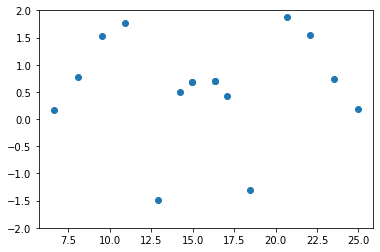

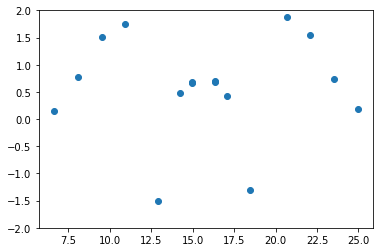

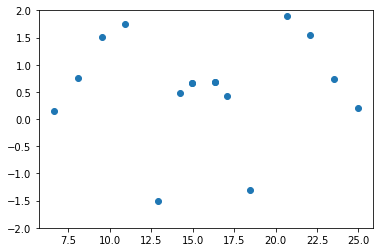

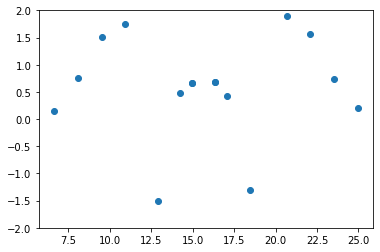

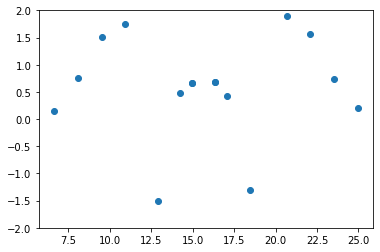

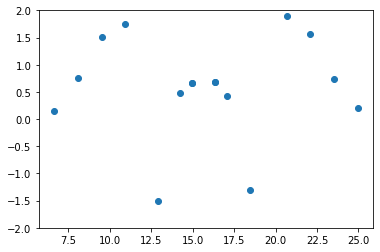

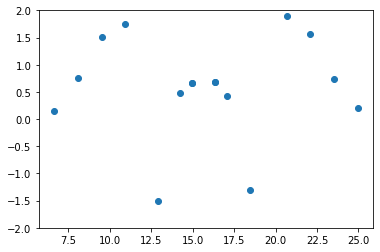

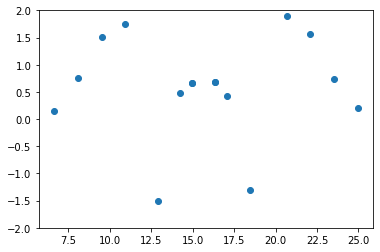

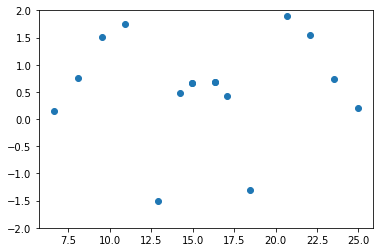

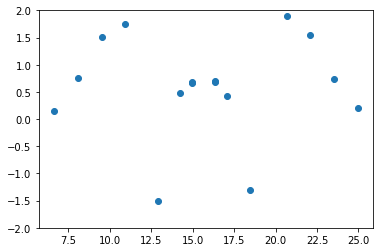

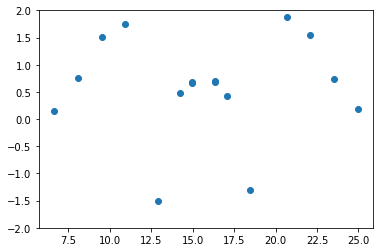

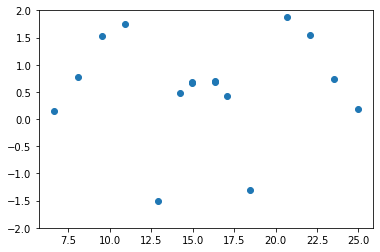

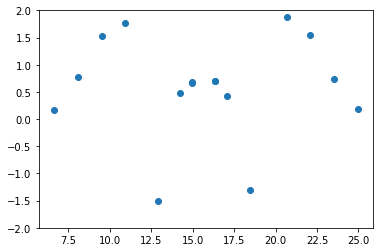

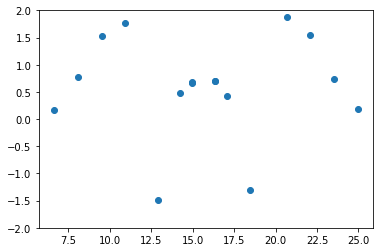

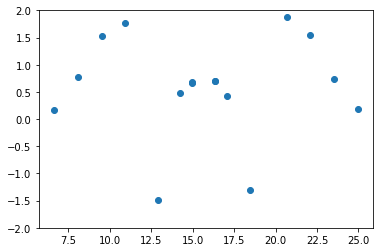

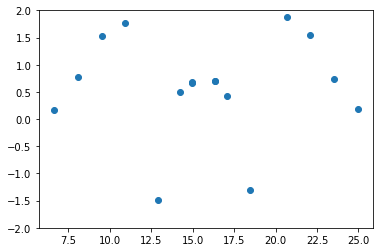

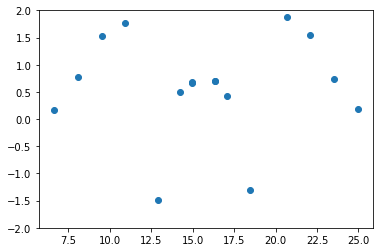

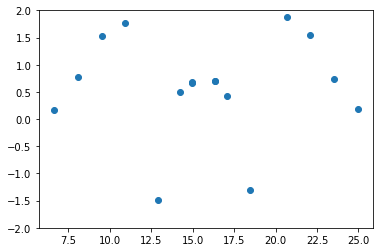

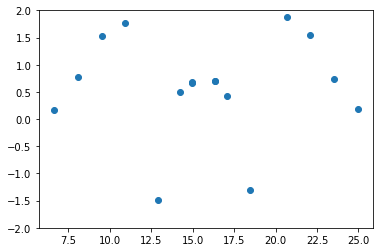

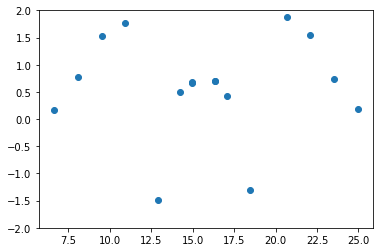

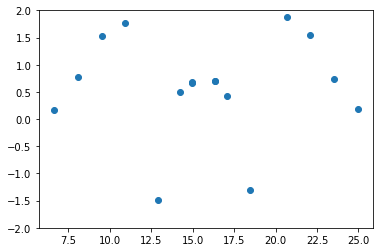

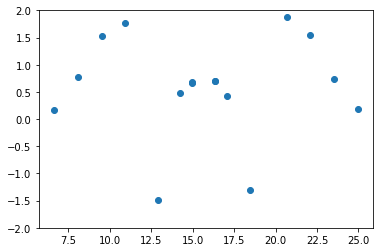

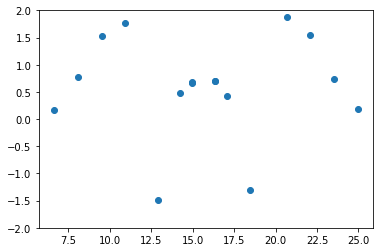

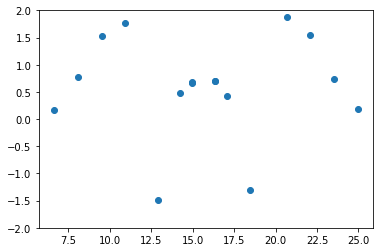

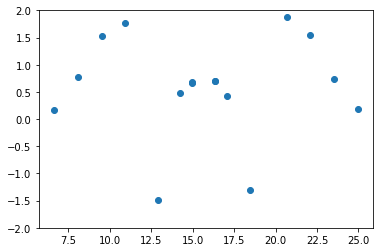

In [63]:
TT    = np.linspace(-120,120,100)
plt.plot(TT, Pulse(TT))
plt.show()
tbt   = sisl.get_sile('Device/siesta.TBT.nc')
tbt.a_dev
idx   = 4 * np.arange(len(tbt.a_dev))+2
count = 0
idx   = []
idx_a = []
for i in range(len(tbt.a_dev)):
    if tbt.geom.atoms[i].no == 4:
        idx  += [tbt.a2p(i)[2]] #[2] for pz orbital
        idx_a+= [i]

for i in range(100):
    _t = TT[i]
    H = H0 + dH(_t,np.zeros(H0.shape))
    plt.scatter(Test.Device.pos_real_space[idx_a,1], np.diag(H[0])[idx])
    plt.ylim([-2.0, 2.0])
    plt.savefig('figs/fig'+str(i)+'.png',dpi = 100)
    plt.show()


Now go to the "figs" folder inside this tutorial folder and do the command

    "convert -delay 5 -loop 0 `ls -v` Oscillating_onsite.gif"

in the terminal. You should be able to see a movie of the onsite elements (In the orthogonal basis) oscillating as the pulse goes through the system.

### ---
Now, the task is again to make the timedependent transport calculation, but this is fairly standard at this point in the tutorial and you can go ahead and do it if you wish, but the main point of this tutorial is to do the bias-calculation and get the Hamiltonian for the biased system. 